In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [3]:
import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [4]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

highalpha = pd.read_csv("../highalpha.csv")
lowalpha = pd.read_csv("../lowalpha.csv")

data = fitsrec_to_pandas(astronn_data)

data['MN_O'] = data['MN_H'] - data['O_H']
data['FE_O'] = data['FE_H'] - data['O_H']
data['MN_MG'] = data['MN_H'] - data['MG_H']
data['FE_MG'] = data['FE_H'] - data['MG_H']
data['MG_FE'] = data['MG_H'] - data['FE_H']

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])

# Create FE_H range arrays
feh_neg = np.linspace(data['FE_H'].min(), 0, 300)  # negative metallicity
feh_pos = np.linspace(0, data['FE_H'].max(), 300)  # positive metallicity

# Compute boundary line
mgfe_neg = 0.12 - 0.13 * feh_neg        # sloped part
mgfe_pos = np.full_like(feh_pos, 0.12)  # flat part at +0.12
feh_line = np.concatenate([feh_neg, feh_pos])
mgfe_line = np.concatenate([mgfe_neg, mgfe_pos])
mgh_line = mgfe_line + feh_line
femg_line = feh_line - mgh_line

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_73527/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_73527/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_73527/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

(-1.05, 0.55)

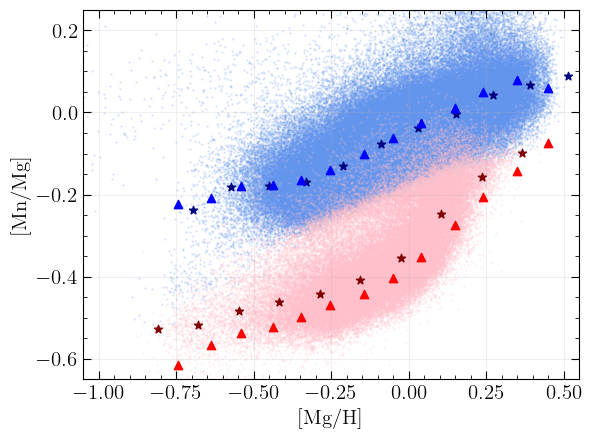

In [5]:
data_low_alpha = data_low_alpha[(data_low_alpha['galz'] < 2) & (data_low_alpha['galz'] > -2) &
                                (data_low_alpha['galr'] < 15) & (data_low_alpha['galr'] > 3)]

data_high_alpha = data_high_alpha[(data_high_alpha['galz'] < 2) & (data_high_alpha['galz'] > -2) &
                                (data_high_alpha['galr'] < 15) & (data_high_alpha['galr'] > 3)]

mnmg_high = compute_binned_median(data_high_alpha, x_col='MG_H', y_col='MN_MG', n_bins=20)
mnmg_low = compute_binned_median(data_low_alpha, x_col='MG_H', y_col='MN_MG', n_bins=20)
femg_high = compute_binned_median(data_high_alpha, x_col='MG_H', y_col='FE_MG', n_bins=20)
femg_low = compute_binned_median(data_low_alpha, x_col='MG_H', y_col='FE_MG', n_bins=20)

mnmg_high = mnmg_high[mnmg_high['count'] >= 100]
mnmg_low  = mnmg_low[mnmg_low['count']  >= 100]
femg_high = femg_high[femg_high['count'] >= 100]
femg_low  = femg_low[femg_low['count']  >= 100]


plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'navy')

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)

In [6]:
data_low_alpha_org = data_low_alpha
data_high_alpha_org = data_high_alpha

N = 10000

def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
down_sample_flag = 0
if down_sample_flag == 1:
    data_low_alpha = downsample(data_low_alpha, N)
    data_high_alpha = downsample(data_high_alpha, N)

print(len(data_high_alpha_org))
print(len(data_low_alpha_org))

print(len(data_high_alpha))

68308
191737
68308


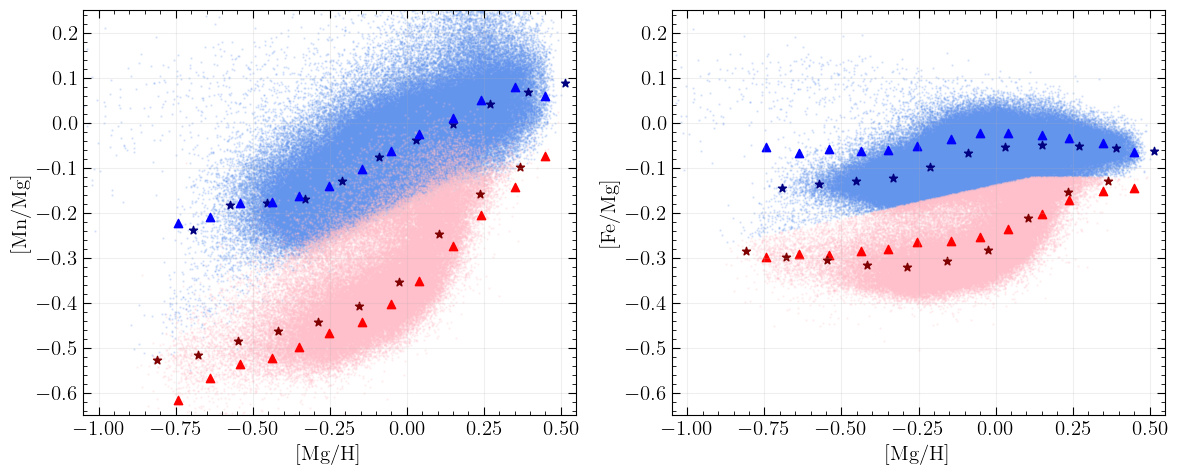

In [7]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'pink', s = 0.5)

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)

plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'navy')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.2, color = 'pink', s = 0.5)

plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')

plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'navy')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

# SFRS

In [8]:
def make_mock_pop(galaxy_model, sfr, n_samples=1000, error_on_met = 0.025):
    mstars = sfr/galaxy_model.tau_star_arr[0] * dt
    cdf_mstars = np.cumsum(mstars)/np.sum(mstars)
    u = np.random.rand(n_samples)
    sampled = np.searchsorted(cdf_mstars, u)
    gal_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O', 'O_Fe', 'Fe_H'])
    gal_df['O_H'] = np.random.normal(loc=galaxy_model.O_H[sampled], scale = error_on_met, size=n_samples)
    gal_df['Fe_H'] = np.random.normal(loc=galaxy_model.Fe_H[sampled], scale = error_on_met, size=n_samples)
    gal_df['Mn_H'] = np.random.normal(loc=galaxy_model.Mn_H[sampled], scale = error_on_met, size=n_samples)
    #gal_df['Fe_O'] = np.random.normal(loc=galaxy_model.Fe_O[sampled], scale = error_on_met, size=n_samples)
    gal_df['Fe_O'] = gal_df['Fe_H'] - gal_df['O_H']
    gal_df['Mn_O'] = gal_df['Mn_H'] - gal_df['O_H']
    gal_df['O_Fe'] = gal_df['O_H'] - gal_df['Fe_H']
    #gal_df['Mn_O'] = np.random.normal(loc=galaxy_model.Mn_O[sampled], scale = error_on_met, size=n_samples)
    #gal_df['O_Fe'] = np.random.normal(loc=galaxy_model.O_Fe[sampled], scale = error_on_met, size=n_samples)
    #gal_df['Fe_H'] = np.random.normal(loc=galaxy_model.Fe_H[sampled], scale = error_on_met, size=n_samples)

    return gal_df

In [9]:
def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
print("dt = ", dt)

dt =  0.014013913913913914


In [10]:
def make_four_plots(galaxy1, galaxy2, galaxy3, sfr1, sfr2, sfr3, tau1s, tau2s):
    galaxy1_df = make_mock_pop(galaxy1, sfr1)
    galaxy2_df = make_mock_pop(galaxy2, sfr2)
    galaxy3_df = make_mock_pop(galaxy3, sfr3)

    fig = plt.figure(figsize=(22,5))
    plt.subplot(1,4,1)
    plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
    plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'pink', s = 0.5)
    plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
    plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

    plt.scatter(galaxy1_df['O_H'], galaxy1_df['Mn_O'], s = 0.5, label = rf'SFR1, $\tau_* = {galaxy1.tau_star_arr[0]} , \eta = {galaxy1.eta_arr[0]} $')
    plt.scatter(galaxy2_df['O_H'], galaxy2_df['Mn_O'], s = 0.5, label = rf'SFR2, $\tau_* = {galaxy2.tau_star_arr[0]} , \eta = {galaxy2.eta_arr[0]} $')
    plt.scatter(galaxy3_df['O_H'], galaxy3_df['Mn_O'], s = 0.5, label = rf'SFR3, $\tau_* = {galaxy3.tau_star_arr[0]} , \eta = {galaxy3.eta_arr[0]} $')
    fig.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=3
    )
    plt.grid('True', alpha = 0.2)

    plt.ylim(-0.65,0.25)
    plt.xlabel('[Mg/H]')
    plt.ylabel('[Mn/Mg]')
    plt.xlim(-1.05,0.55)


    plt.subplot(1,4,2)
    plt.scatter(data_low_alpha['FE_H'], data_low_alpha['MG_FE'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
    plt.scatter(data_high_alpha['FE_H'], data_high_alpha['MG_FE'], alpha = 0.2, color = 'pink', s = 0.5)

    plt.scatter(galaxy1_df['Fe_H'], galaxy1_df['O_Fe'], s = 0.5)
    plt.scatter(galaxy2_df['Fe_H'], galaxy2_df['O_Fe'], s = 0.5)
    plt.scatter(galaxy3_df['Fe_H'], galaxy3_df['O_Fe'], s = 0.5)

    plt.grid('True', alpha = 0.2)
    plt.xlabel('[Fe/H]')
    plt.ylabel('[Mg/Fe]')
    plt.ylim(-0.2,0.6)
    plt.xlim(-1.5,0.5)

    plt.subplot(1,4,3)
    plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
    plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.2, color = 'pink', s = 0.5)
    plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
    plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

    plt.scatter(galaxy1_df['O_H'], galaxy1_df['Fe_O'], s = 0.5)
    plt.scatter(galaxy2_df['O_H'], galaxy2_df['Fe_O'], s = 0.5)
    plt.scatter(galaxy3_df['O_H'], galaxy3_df['Fe_O'], s = 0.5)

    plt.grid('True', alpha = 0.2)
    plt.xlabel('[Mg/H]')
    plt.ylabel('[Fe/Mg]')
    plt.ylim(-0.65,0.25)
    plt.xlim(-1.05,0.55)

    plt.subplot(1,4,4)
    plt.plot(t_array, sfr1, label = rf'$SFR_1 : \tau_1 = {tau1s[0]}, \tau_2 = {tau2s[0]}$')
    plt.plot(t_array, sfr2, label = rf'$SFR_2 : \tau_1 = {tau1s[1]}, \tau_2 = {tau2s[1]}$')
    plt.plot(t_array, sfr3, label = rf'$SFR_3 : \tau_1 = {tau1s[2]}, \tau_2 = {tau2s[2]}$')

    plt.grid('True', alpha = 0.2)
    plt.legend()
    plt.xlabel('t (Gyrs)')
    plt.ylabel('SFR')

    plt.tight_layout()

In [11]:
def make_triple_plot(galaxy1, galaxy2, galaxy3, sfr1, sfr2, sfr3, tau1s, tau2s):
    galaxy1_df = make_mock_pop(galaxy1, sfr1)
    galaxy2_df = make_mock_pop(galaxy2, sfr2)
    galaxy3_df = make_mock_pop(galaxy3, sfr3)

    fig = plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
    plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'pink', s = 0.5)
    plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
    plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

    plt.scatter(galaxy1_df['O_H'], galaxy1_df['Mn_O'], s = 0.5, label = rf'SFR1, $\tau_* = {galaxy1.tau_star_arr[0]} , \eta = {galaxy1.eta_arr[0]} $')
    plt.scatter(galaxy2_df['O_H'], galaxy2_df['Mn_O'], s = 0.5, label = rf'SFR2, $\tau_* = {galaxy2.tau_star_arr[0]} , \eta = {galaxy2.eta_arr[0]} $')
    plt.scatter(galaxy3_df['O_H'], galaxy3_df['Mn_O'], s = 0.5, label = rf'SFR3, $\tau_* = {galaxy3.tau_star_arr[0]} , \eta = {galaxy3.eta_arr[0]} $')
    fig.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=3
    )
    plt.grid('True', alpha = 0.2)

    plt.ylim(-0.65,0.25)
    plt.xlabel('[Mg/H]')
    plt.ylabel('[Mn/Mg]')
    plt.xlim(-1.05,0.55)


    plt.subplot(1,3,2)
    plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
    plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.2, color = 'pink', s = 0.5)
    plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
    plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

    plt.scatter(galaxy1_df['O_H'], galaxy1_df['Fe_O'], s = 0.5)
    plt.scatter(galaxy2_df['O_H'], galaxy2_df['Fe_O'], s = 0.5)
    plt.scatter(galaxy3_df['O_H'], galaxy3_df['Fe_O'], s = 0.5)

    plt.grid('True', alpha = 0.2)
    plt.xlabel('[Mg/H]')
    plt.ylabel('[Fe/Mg]')
    plt.ylim(-0.65,0.25)
    plt.xlim(-1.05,0.55)

    plt.subplot(1,3,3)
    plt.plot(t_array, sfr1, label = rf'$SFR_1 : \tau_1 = {tau1s[0]}, \tau_2 = {tau2s[0]}$')
    plt.plot(t_array, sfr2, label = rf'$SFR_2 : \tau_1 = {tau1s[1]}, \tau_2 = {tau2s[1]}$')
    plt.plot(t_array, sfr3, label = rf'$SFR_3 : \tau_1 = {tau1s[2]}, \tau_2 = {tau2s[2]}$')

    plt.grid('True', alpha = 0.2)
    plt.legend()
    plt.xlabel('t (Gyrs)')
    plt.ylabel('SFR')

    plt.tight_layout()

# tau* and eta at default, changing SFR params to best found

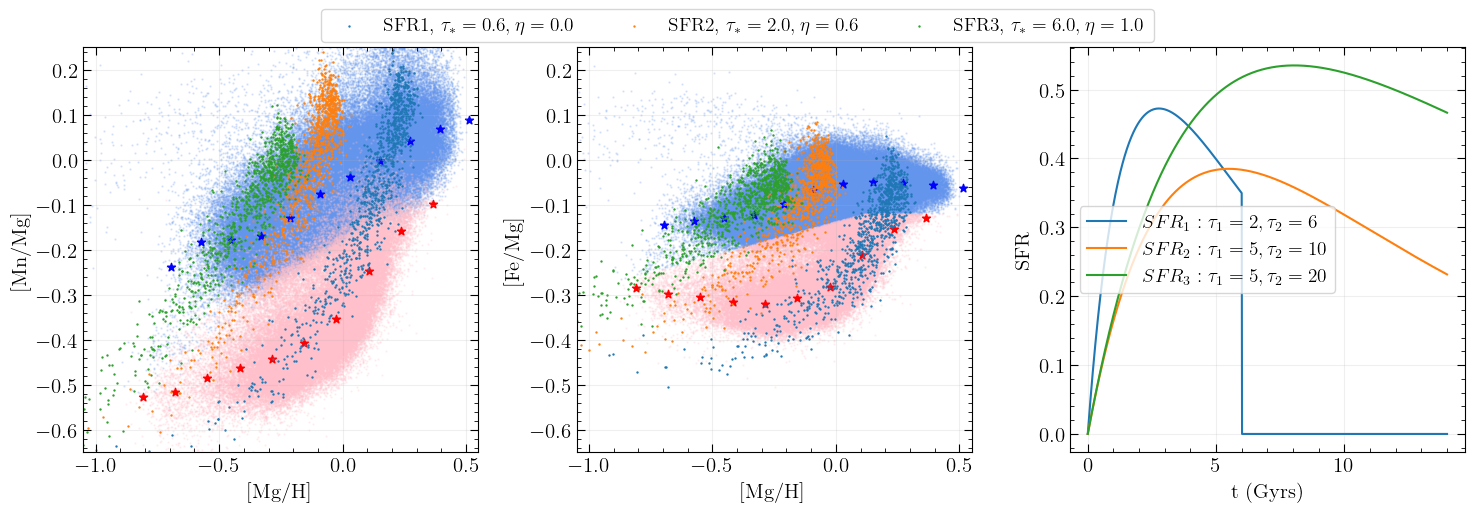

In [12]:
tau_stars_2024 = [0.6, 2.0, 6.0]
etas_2024 = [0, 0.6, 1.0]

tau_1s = [2, 5, 5]
tau_2s = [6, 10, 20]
sfr_1 = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_2 = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_3 = rise_fall(t_array, tau_1s[2], tau_2s[2])
mask_1 = t_array > 6
sfr_1[mask_1] = 1e-10

gal1_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_1, tau_star=tau_stars_2024[0], eta = etas_2024[0])
gal2_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_2, tau_star=tau_stars_2024[1], eta = etas_2024[1])
gal3_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_3, tau_star=tau_stars_2024[2], eta = etas_2024[2])

make_triple_plot(gal1_rf, gal2_rf, gal3_rf, sfr_1, sfr_2, sfr_3, tau_1s, tau_2s)

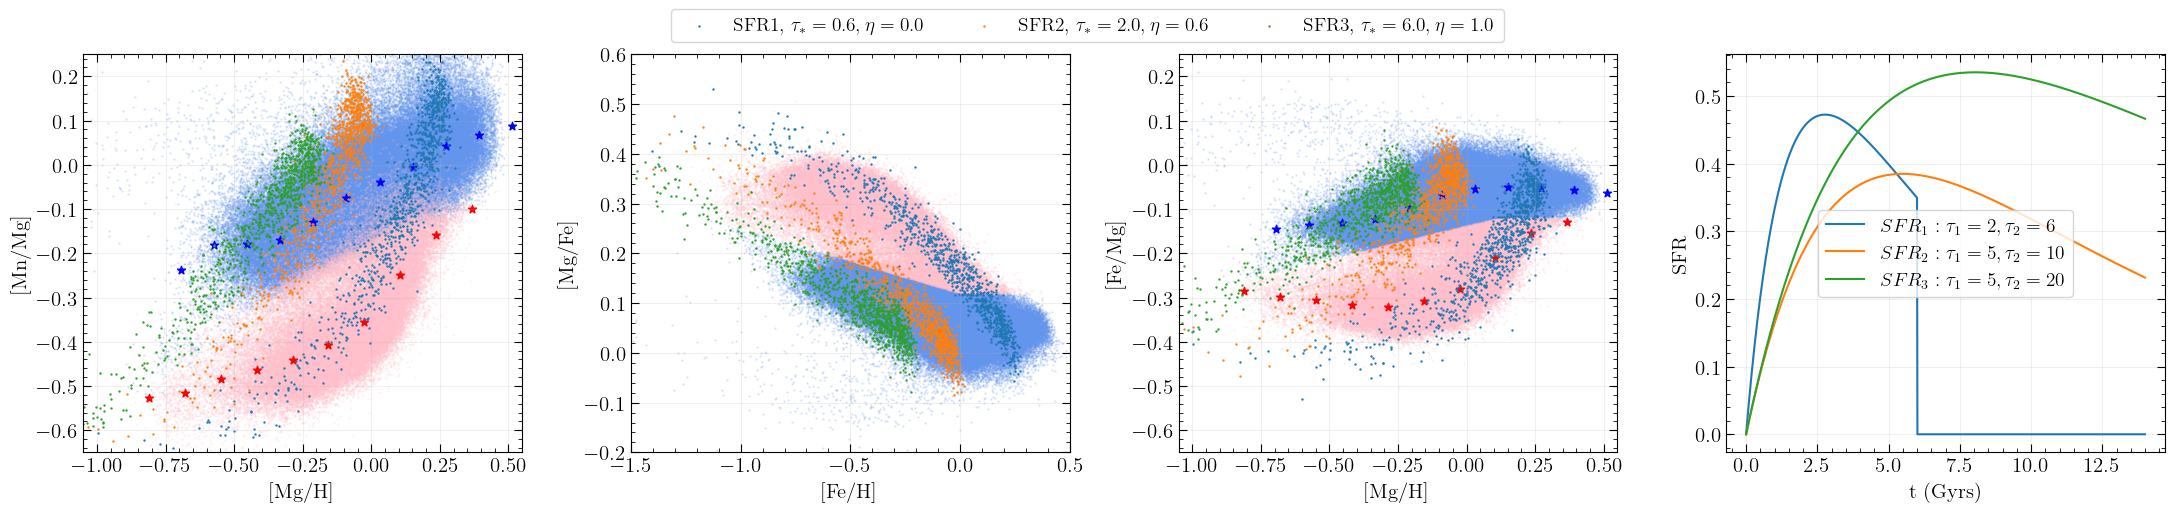

In [13]:
make_four_plots(gal1_rf, gal2_rf, gal3_rf, sfr_1, sfr_2, sfr_3, tau_1s, tau_2s)

# SFR params at default, changing tau* and eta

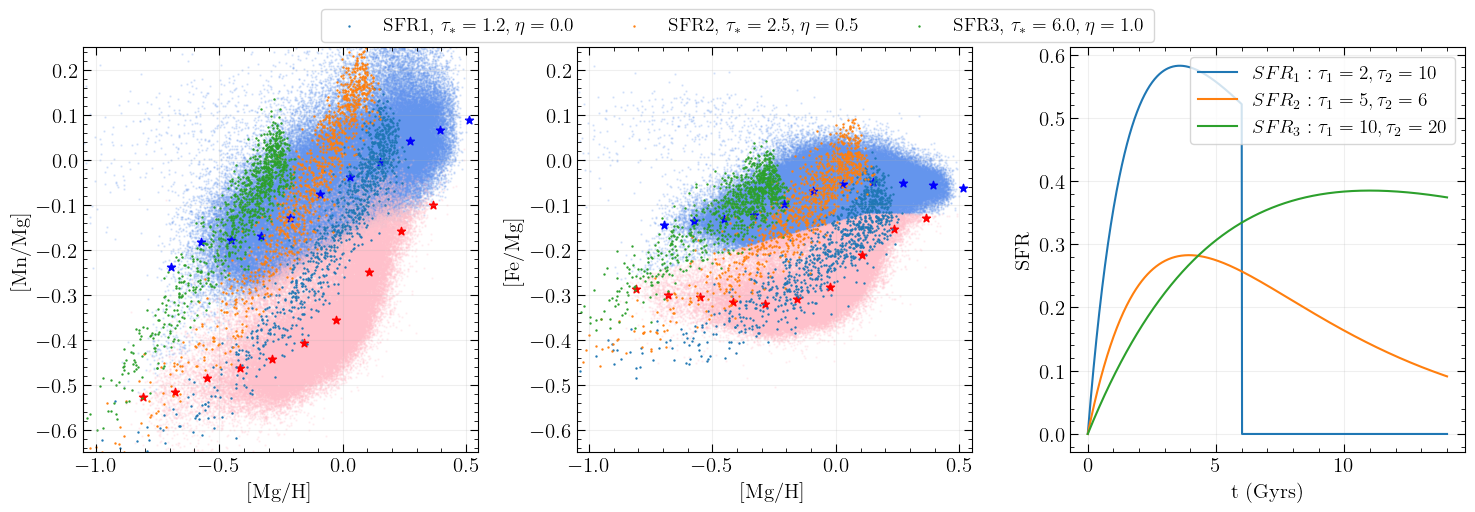

In [14]:
#tau_stars_2024 = [0.6, 2.0, 6.0]
tau_stars_2024 = [1.2, 2.5, 6.0]
etas_2024 = [0, 0.5, 1.0]

tau_1s = [2, 5, 10]
tau_2s = [10, 6, 20]
sfr_1 = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_2 = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_3 = rise_fall(t_array, tau_1s[2], tau_2s[2])
mask_1 = t_array > 6
sfr_1[mask_1] = 1e-10

gal1_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_1, tau_star=tau_stars_2024[0], eta = etas_2024[0])
gal2_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_2, tau_star=tau_stars_2024[1], eta = etas_2024[1])
gal3_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_3, tau_star=tau_stars_2024[2], eta = etas_2024[2])

make_triple_plot(gal1_rf, gal2_rf, gal3_rf, sfr_1, sfr_2, sfr_3, tau_1s, tau_2s)

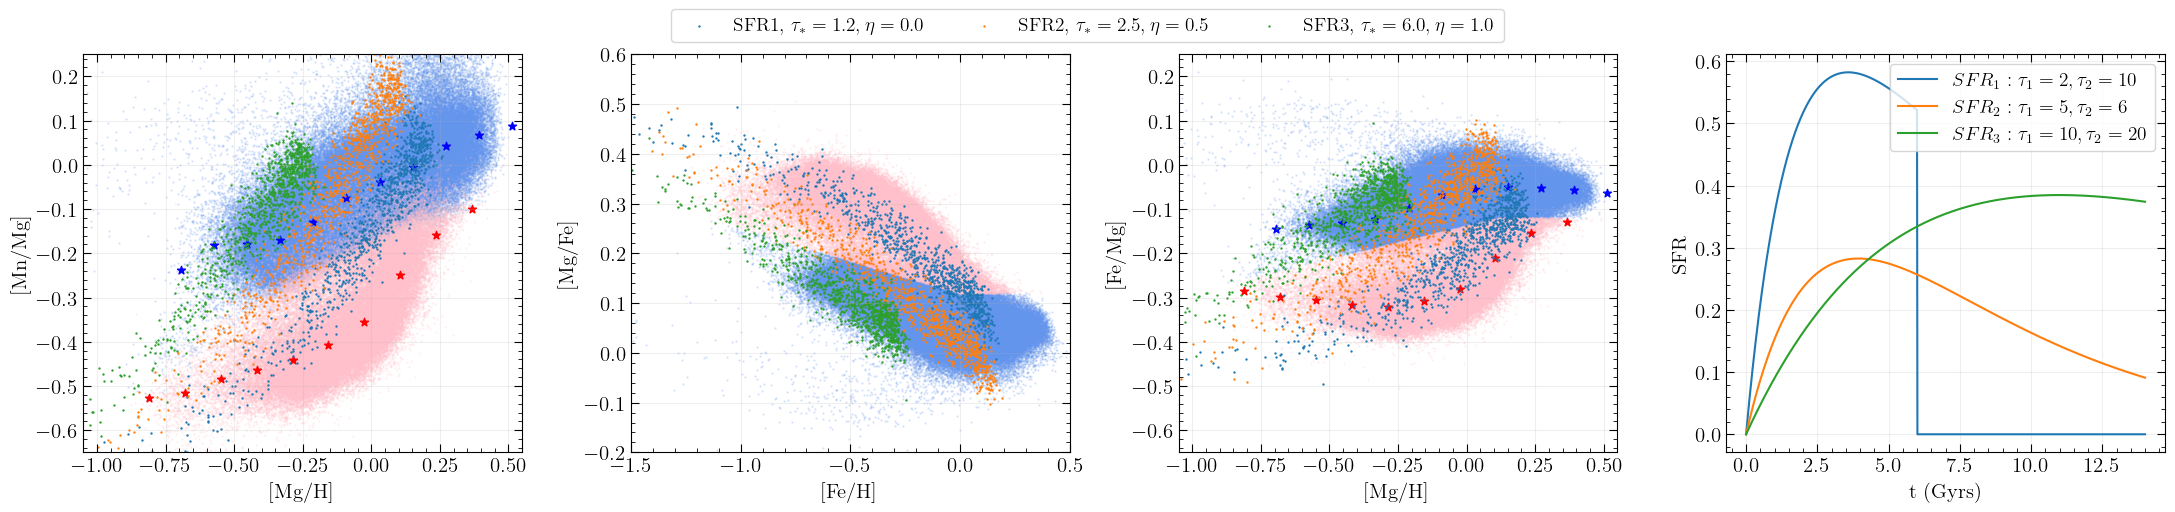

In [15]:
make_four_plots(gal1_rf, gal2_rf, gal3_rf, sfr_1, sfr_2, sfr_3, tau_1s, tau_2s)

# Combine best found values

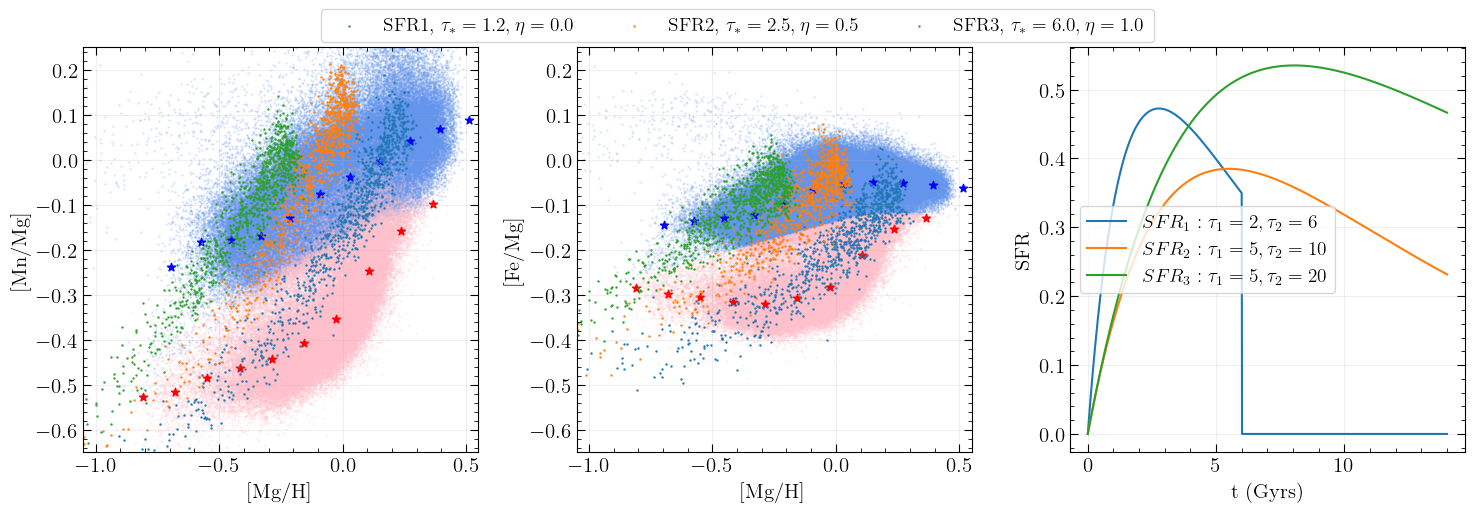

In [16]:
#tau_stars_2024 = [0.6, 2.0, 6.0]
tau_stars_2024 = [1.2, 2.5, 6.0]
etas_2024 = [0, 0.5, 1.0]
tau_1s = [2, 5, 5]
tau_2s = [6, 10, 20]
sfr_1 = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_2 = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_3 = rise_fall(t_array, tau_1s[2], tau_2s[2])
mask_1 = t_array > 6
sfr_1[mask_1] = 1e-10

gal1_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_1, tau_star=tau_stars_2024[0], eta = etas_2024[0])
gal2_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_2, tau_star=tau_stars_2024[1], eta = etas_2024[1])
gal3_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_3, tau_star=tau_stars_2024[2], eta = etas_2024[2])

make_triple_plot(gal1_rf, gal2_rf, gal3_rf, sfr_1, sfr_2, sfr_3, tau_1s, tau_2s)

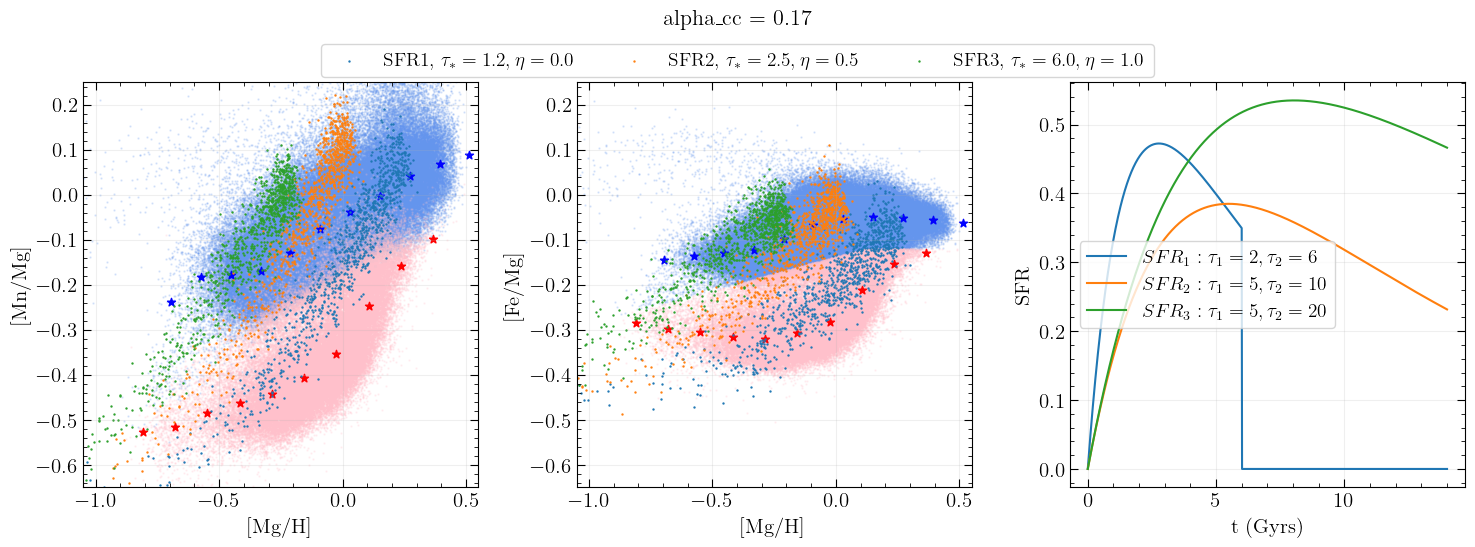

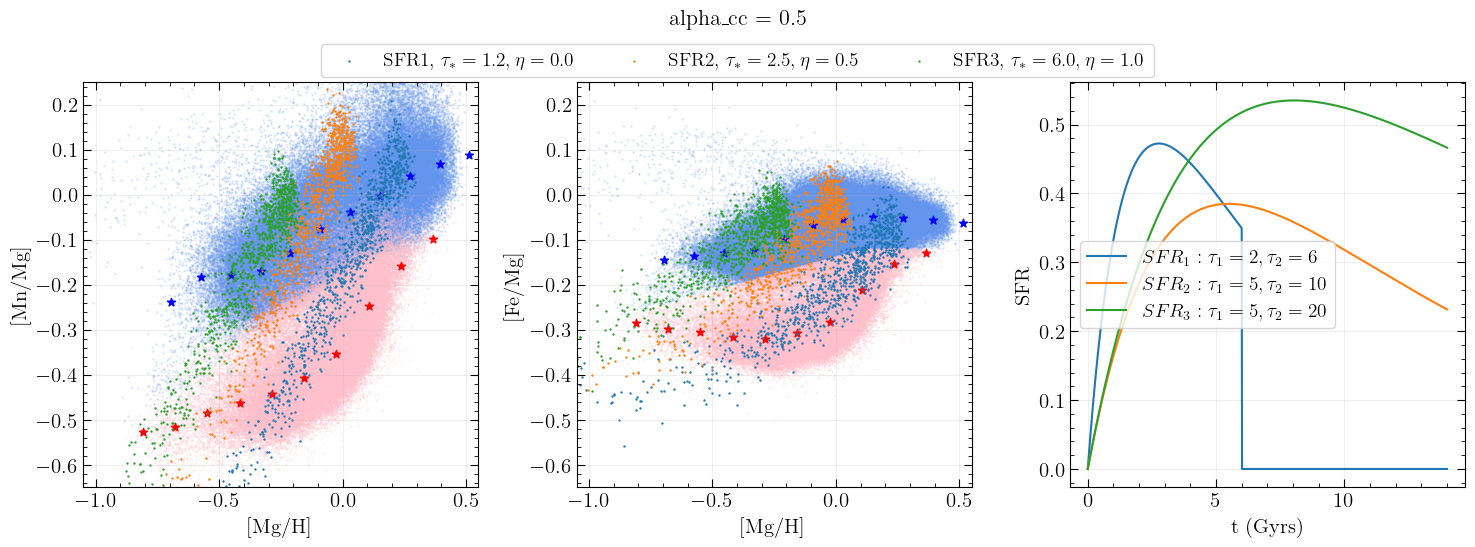

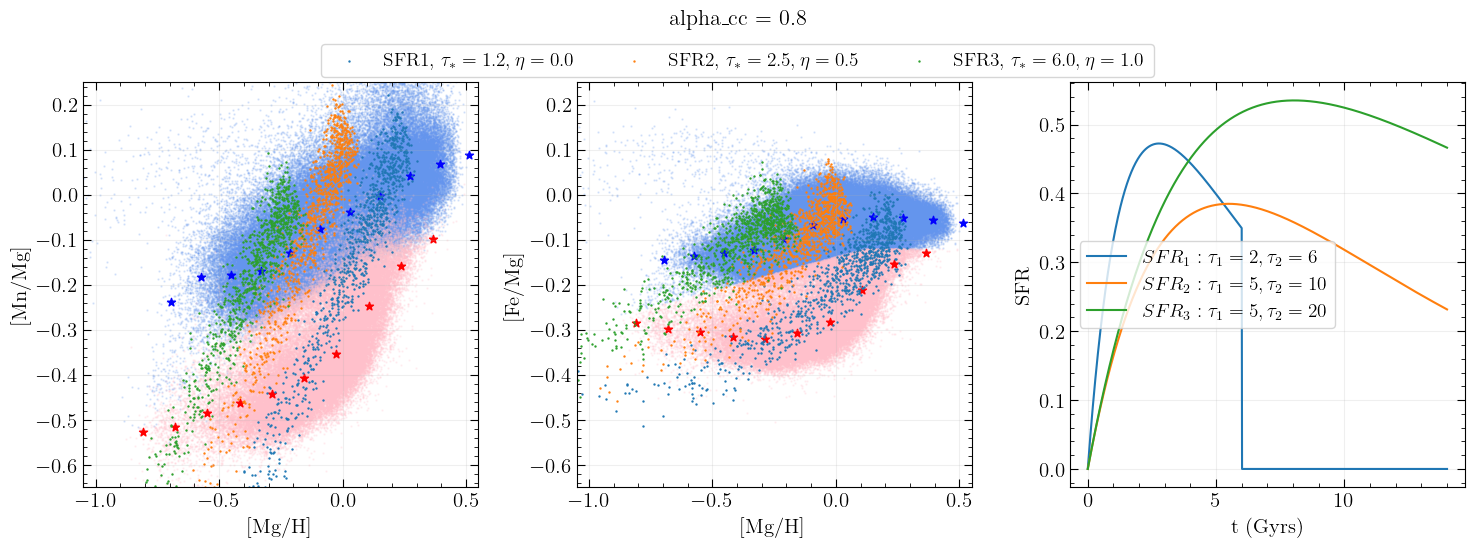

In [17]:
#tau_stars_2024 = [0.6, 2.0, 6.0]
tau_stars_2024 = [1.2, 2.5, 6.0]
etas_2024 = [0, 0.5, 1.0]
tau_1s = [2, 5, 5]
tau_2s = [6, 10, 20]
sfr_1 = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_2 = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_3 = rise_fall(t_array, tau_1s[2], tau_2s[2])
mask_1 = t_array > 6
sfr_1[mask_1] = 1e-10

alpha_ccs = [0.17, 0.5, 0.8]

for i in range(len(alpha_ccs)):
    gal1_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_1, tau_star=tau_stars_2024[0], eta = etas_2024[0], alpha_cc_Mn=alpha_ccs[i])
    gal2_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_2, tau_star=tau_stars_2024[1], eta = etas_2024[1], alpha_cc_Mn=alpha_ccs[i])
    gal3_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_3, tau_star=tau_stars_2024[2], eta = etas_2024[2], alpha_cc_Mn=alpha_ccs[i])

    make_triple_plot(gal1_rf, gal2_rf, gal3_rf, sfr_1, sfr_2, sfr_3, tau_1s, tau_2s)
    plt.suptitle(f'alpha_cc = {alpha_ccs[i]}', y=1.1, fontsize=16)

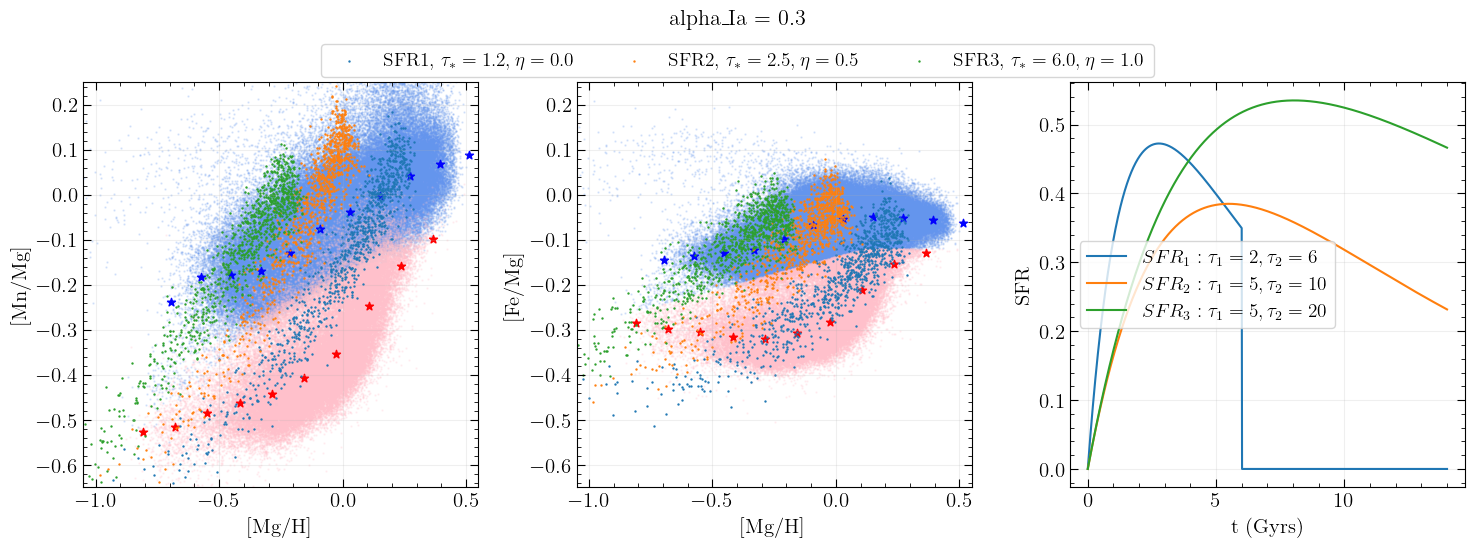

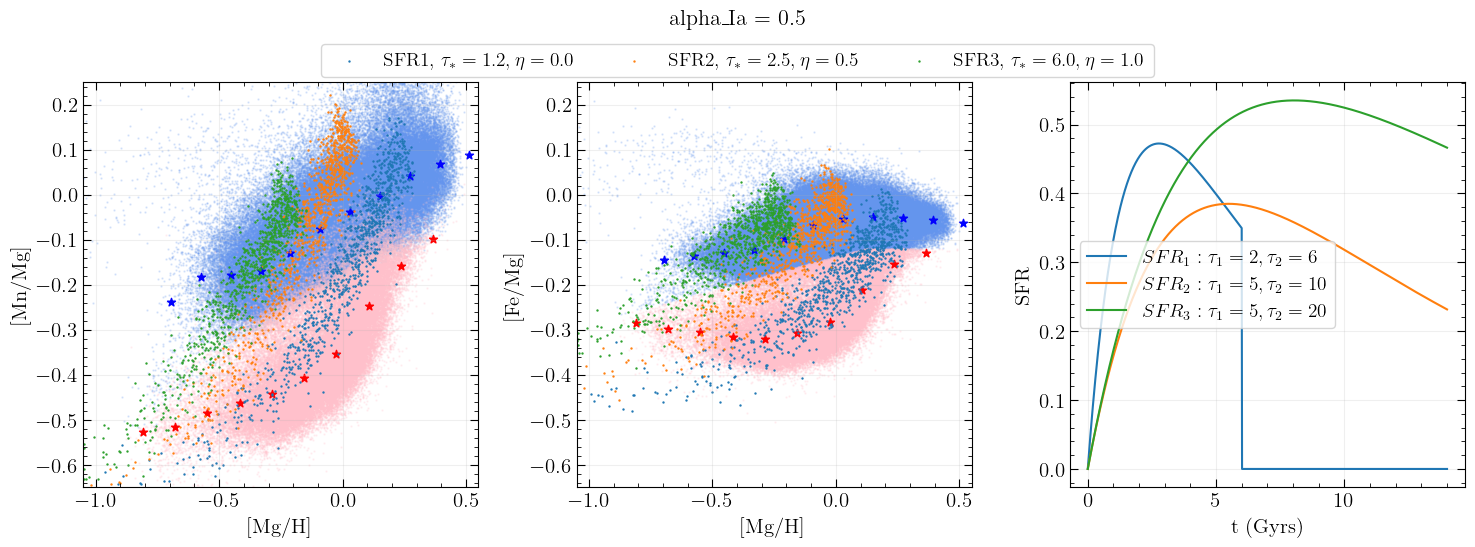

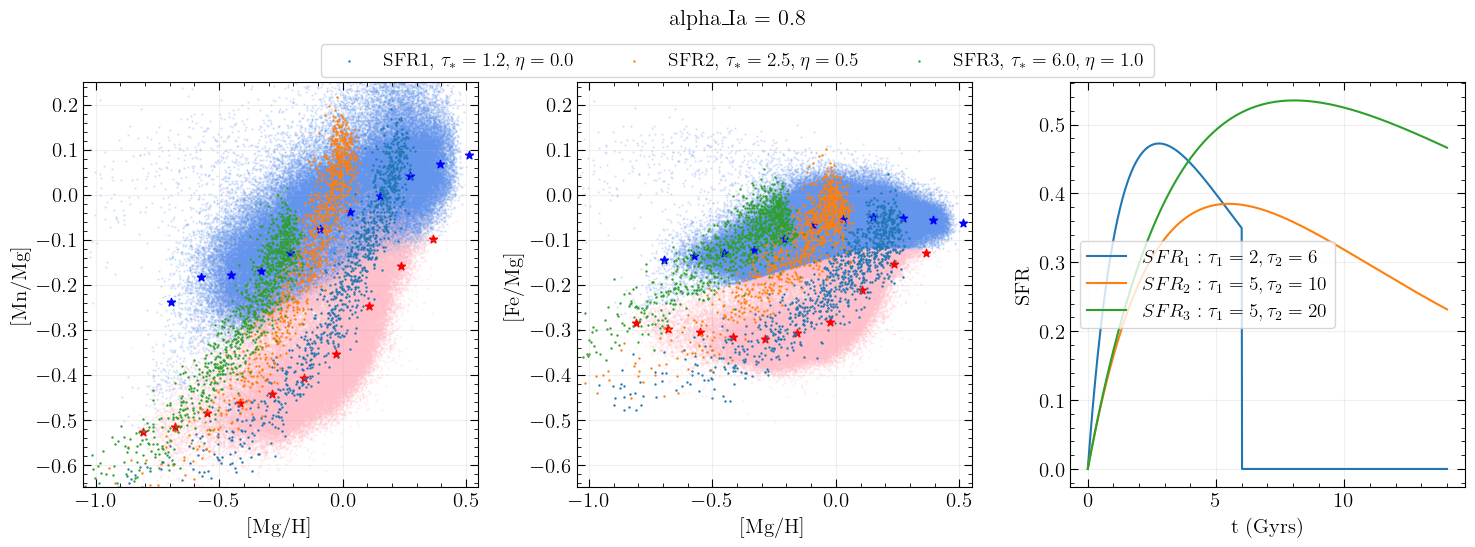

In [18]:
#tau_stars_2024 = [0.6, 2.0, 6.0]
tau_stars_2024 = [1.2, 2.5, 6.0]
etas_2024 = [0, 0.5, 1.0]
tau_1s = [2, 5, 5]
tau_2s = [6, 10, 20]
sfr_1 = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_2 = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_3 = rise_fall(t_array, tau_1s[2], tau_2s[2])
mask_1 = t_array > 6
sfr_1[mask_1] = 1e-10

alpha_Ias = [0.30, 0.5, 0.8]

for i in range(len(alpha_Ias)):
    gal1_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_1, tau_star=tau_stars_2024[0], eta = etas_2024[0], alpha_Ia_Mn=alpha_Ias[i])
    gal2_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_2, tau_star=tau_stars_2024[1], eta = etas_2024[1], alpha_Ia_Mn=alpha_Ias[i])
    gal3_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_3, tau_star=tau_stars_2024[2], eta = etas_2024[2], alpha_Ia_Mn=alpha_Ias[i])

    make_triple_plot(gal1_rf, gal2_rf, gal3_rf, sfr_1, sfr_2, sfr_3, tau_1s, tau_2s)
    plt.suptitle(f'alpha_Ia = {alpha_Ias[i]}', y=1.1, fontsize=16)

# Best to my opinion

Text(0.5, 1.1, 'alpha_Ia = 0.8, alpha_cc = 0.5')

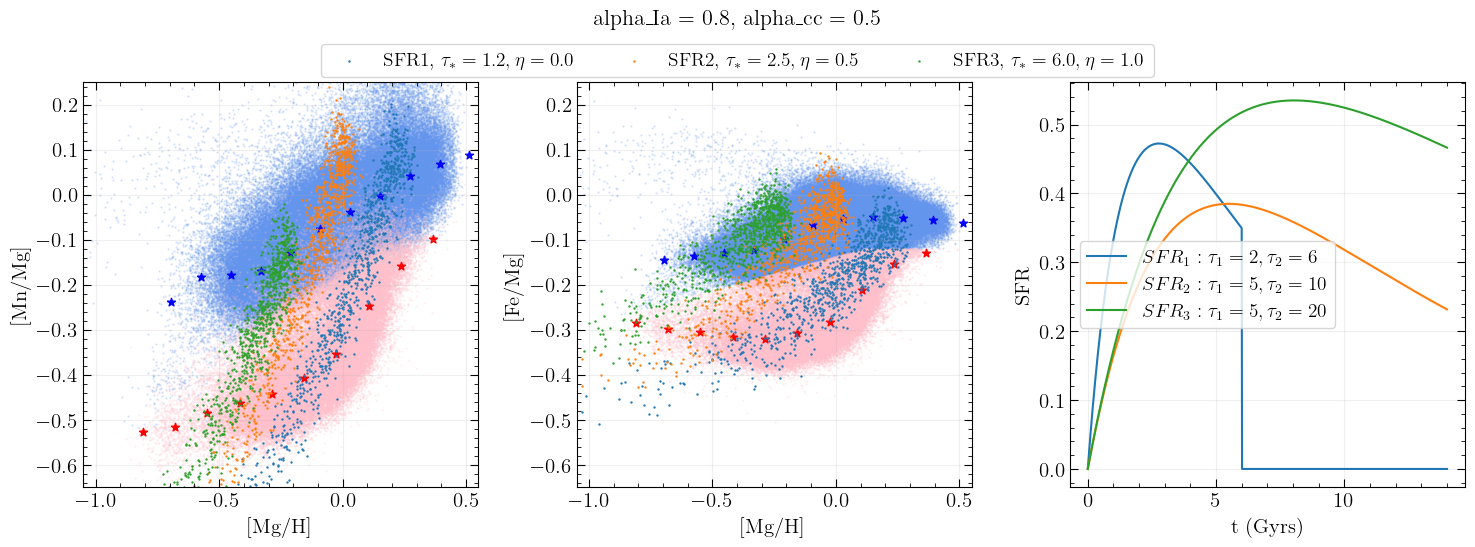

In [19]:
#tau_stars_2024 = [0.6, 2.0, 6.0]
tau_stars_2024 = [1.2, 2.5, 6.0]
etas_2024 = [0, 0.5, 1.0]
tau_1s = [2, 5, 5]
tau_2s = [6, 10, 20]
sfr_1 = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_2 = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_3 = rise_fall(t_array, tau_1s[2], tau_2s[2])
mask_1 = t_array > 6
sfr_1[mask_1] = 1e-10

alpha_Ia_best = 0.8
alpha_cc_best = 0.5

gal1_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_1, tau_star=tau_stars_2024[0], eta = etas_2024[0], alpha_Ia_Mn=alpha_Ia_best, alpha_cc_Mn=alpha_cc_best)
gal2_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_2, tau_star=tau_stars_2024[1], eta = etas_2024[1], alpha_Ia_Mn=alpha_Ia_best, alpha_cc_Mn=alpha_cc_best)
gal3_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_3, tau_star=tau_stars_2024[2], eta = etas_2024[2], alpha_Ia_Mn=alpha_Ia_best, alpha_cc_Mn=alpha_cc_best)

make_triple_plot(gal1_rf, gal2_rf, gal3_rf, sfr_1, sfr_2, sfr_3, tau_1s, tau_2s)
plt.suptitle(f'alpha_Ia = {alpha_Ia_best}, alpha_cc = {alpha_cc_best}', y=1.1, fontsize=16)

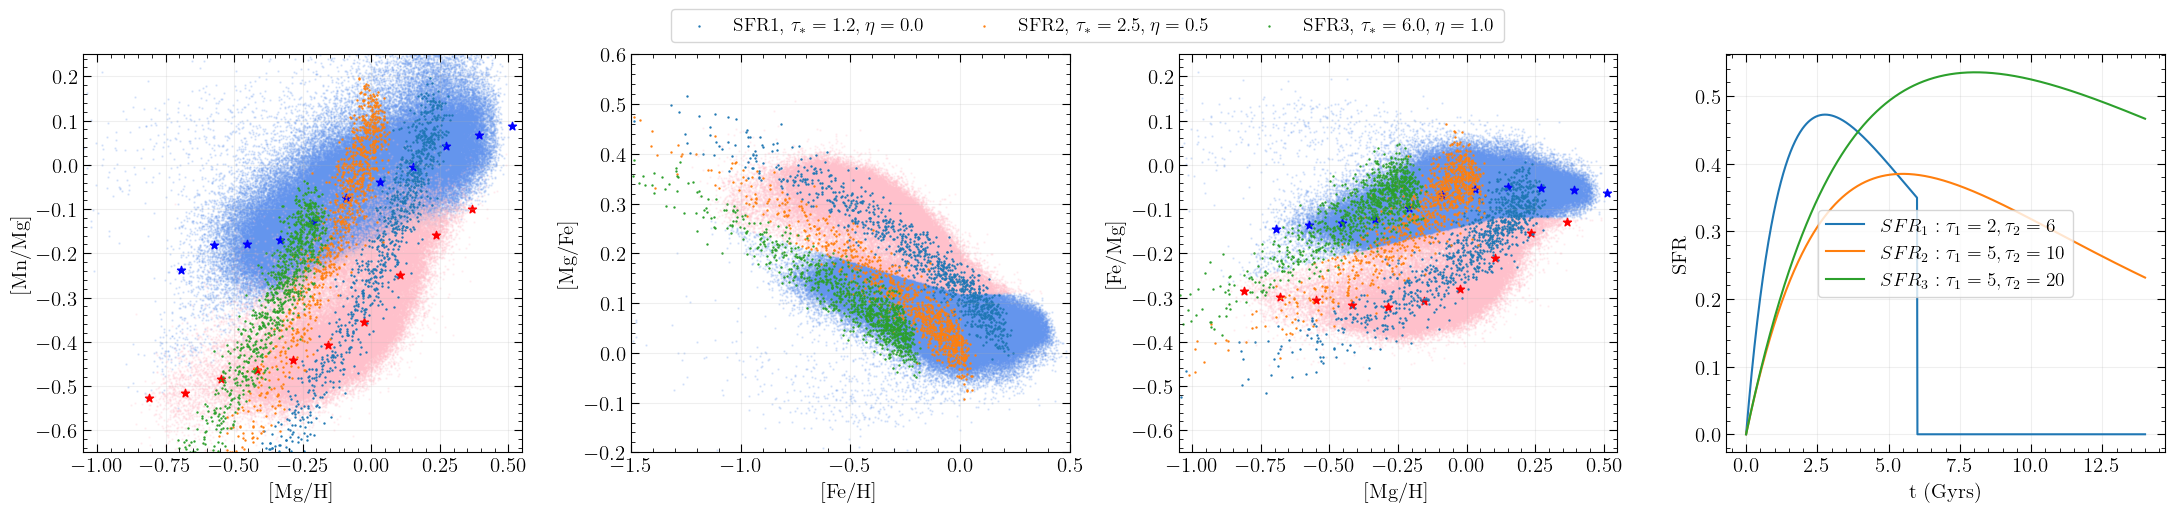

In [20]:
make_four_plots(gal1_rf, gal2_rf, gal3_rf, sfr_1, sfr_2, sfr_3, tau_1s, tau_2s)

# More populated

In [21]:
tau_stars_more = [1.2, 2.5, 6.0]
etas_more = [0, 0.1, 0.2, 0.5, 0.6, 0.7, 0.8, 1.0, 1.2]

tau_stars_1 = [1, 1.2, 1.5]
etas_1 = [0, 0.01, 0.02]

tau_stars_2 = [2, 2.5, 3]
etas_2 = [0.4, 0.5, 0.6]

tau_stars_3 = [5, 6, 7]
etas_3 = [0.9, 1, 1.1]

tau_1s = [2, 5, 5]
tau_2s = [6, 10, 20]
sfr_1 = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_2 = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_3 = rise_fall(t_array, tau_1s[2], tau_2s[2])

mask_1 = t_array > 6
sfr_1[mask_1] = 1e-10

#alpha_Ia_best = 0.8
#alpha_cc_best = 0.5
alpha_Ia_best = 0.3
alpha_cc_best = 0.17

sfr_1_gals = []
sfr_2_gals = []
sfr_3_gals = []

for eta in etas_1:
    for tau_star in tau_stars_1:
        sfr_1_gals.append(evo.Galaxy(t_array=t_array, m_g_array=sfr_1, tau_star=tau_star, eta = eta, alpha_Ia_Mn=alpha_Ia_best, alpha_cc_Mn=alpha_cc_best))

for eta in etas_2:
    for tau_star in tau_stars_2:
        sfr_2_gals.append(evo.Galaxy(t_array=t_array, m_g_array=sfr_2, tau_star=tau_star, eta = eta, alpha_Ia_Mn=alpha_Ia_best, alpha_cc_Mn=alpha_cc_best))


for eta in etas_3:
    for tau_star in tau_stars_3:
        sfr_3_gals.append(evo.Galaxy(t_array=t_array, m_g_array=sfr_3, tau_star=tau_star, eta = eta, alpha_Ia_Mn=alpha_Ia_best, alpha_cc_Mn=alpha_cc_best))

In [22]:
len(sfr_1_gals)

9

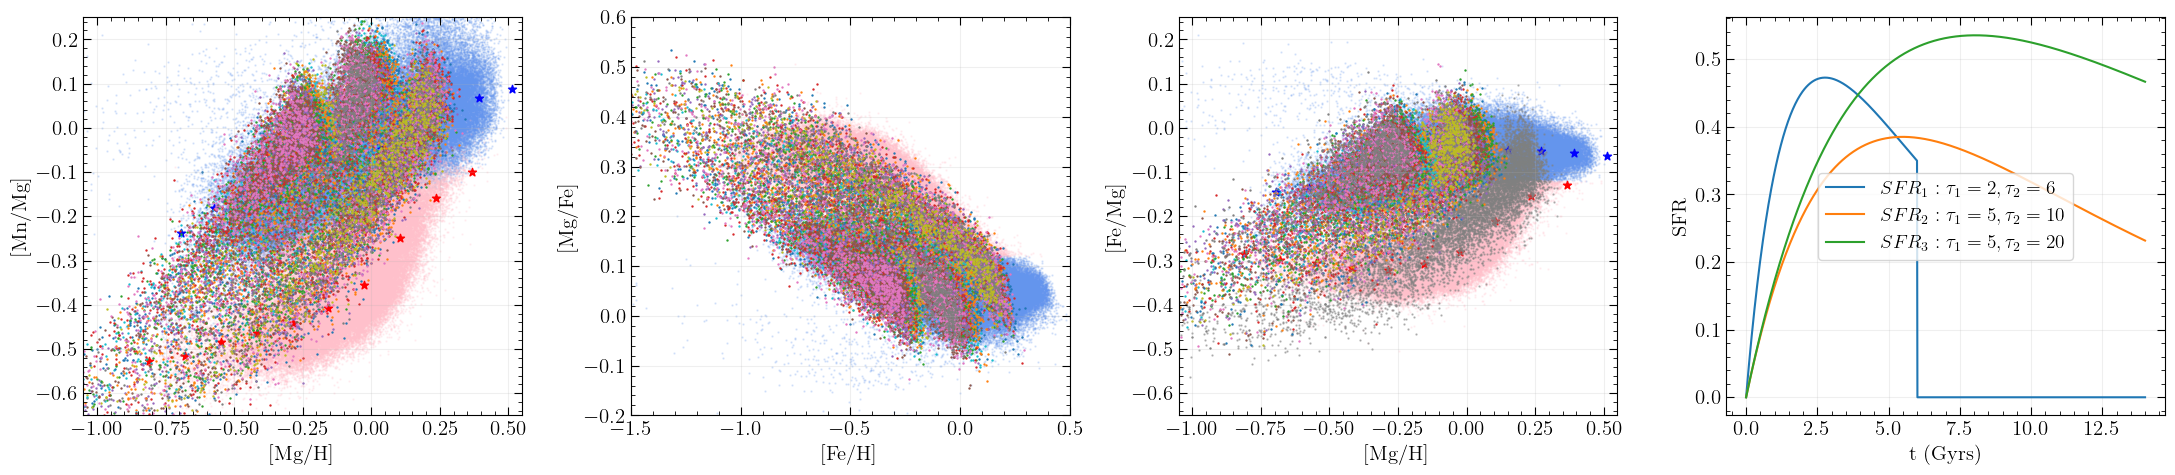

In [23]:
gal1_dfs = []
gal2_dfs = []
gal3_dfs = []

err_on_met = 0.03

for i in range(len(sfr_1_gals)):
    gal1_dfs.append(make_mock_pop(sfr_1_gals[i], sfr_1, error_on_met=err_on_met))

for i in range(len(sfr_2_gals)):
    gal2_dfs.append(make_mock_pop(sfr_2_gals[i], sfr_2, error_on_met=err_on_met))

for i in range(len(sfr_3_gals)):
    gal3_dfs.append(make_mock_pop(sfr_3_gals[i], sfr_3, error_on_met=err_on_met))

fig = plt.figure(figsize=(22,5))
plt.subplot(1,4,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gal1_dfs)):
    galaxy1_df = gal1_dfs[i]
    galaxy1 = sfr_1_gals[i]
    plt.scatter(galaxy1_df['O_H'], galaxy1_df['Mn_O'], s = 0.5, label = rf'SFR1, $\tau_* = {galaxy1.tau_star_arr[0]} , \eta = {galaxy1.eta_arr[0]} $')

for i in range(len(gal2_dfs)):
    galaxy2_df = gal2_dfs[i]
    galaxy2 = sfr_2_gals[i]
    plt.scatter(galaxy2_df['O_H'], galaxy2_df['Mn_O'], s = 0.5, label = rf'SFR1, $\tau_* = {galaxy2.tau_star_arr[0]} , \eta = {galaxy2.eta_arr[0]} $')

for i in range(len(gal3_dfs)):
    galaxy3_df = gal3_dfs[i]
    galaxy3 = sfr_3_gals[i]
    plt.scatter(galaxy3_df['O_H'], galaxy3_df['Mn_O'], s = 0.5, label = rf'SFR1, $\tau_* = {galaxy3.tau_star_arr[0]} , \eta = {galaxy3.eta_arr[0]} $')


#fig.legend(loc="upper center",bbox_to_anchor=(0.5, 1.05),ncol=3)

plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,4,2)
plt.scatter(data_low_alpha['FE_H'], data_low_alpha['MG_FE'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['FE_H'], data_high_alpha['MG_FE'], alpha = 0.2, color = 'pink', s = 0.5)

for i in range(len(gal1_dfs)):
    galaxy1_df = gal1_dfs[i]
    galaxy1 = sfr_1_gals[i]
    plt.scatter(galaxy1_df['Fe_H'], galaxy1_df['O_Fe'], s = 0.5, label = rf'SFR1, $\tau_* = {galaxy1.tau_star_arr[0]} , \eta = {galaxy1.eta_arr[0]} $')

for i in range(len(gal2_dfs)):
    galaxy2_df = gal2_dfs[i]
    galaxy2 = sfr_2_gals[i]
    plt.scatter(galaxy2_df['Fe_H'], galaxy2_df['O_Fe'], s = 0.5, label = rf'SFR1, $\tau_* = {galaxy2.tau_star_arr[0]} , \eta = {galaxy2.eta_arr[0]} $')

for i in range(len(gal3_dfs)):
    galaxy3_df = gal3_dfs[i]
    galaxy3 = sfr_3_gals[i]
    plt.scatter(galaxy3_df['Fe_H'], galaxy3_df['O_Fe'], s = 0.5, label = rf'SFR1, $\tau_* = {galaxy3.tau_star_arr[0]} , \eta = {galaxy3.eta_arr[0]} $')




plt.grid('True', alpha = 0.2)
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.ylim(-0.2,0.6)
plt.xlim(-1.5,0.5)

plt.subplot(1,4,3)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.2, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

for i in range(len(gal1_dfs)):
    galaxy1_df = gal1_dfs[i]
    galaxy1 = sfr_1_gals[i]
    plt.scatter(galaxy1_df['O_H'], galaxy1_df['Fe_O'], s = 0.5, label = rf'SFR1, $\tau_* = {galaxy1.tau_star_arr[0]} , \eta = {galaxy1.eta_arr[0]} $', color = 'gray', alpha = 0.5)

for i in range(len(gal2_dfs)):
    galaxy2_df = gal2_dfs[i]
    galaxy2 = sfr_2_gals[i]
    plt.scatter(galaxy2_df['O_H'], galaxy2_df['Fe_O'], s = 0.5, label = rf'SFR1, $\tau_* = {galaxy2.tau_star_arr[0]} , \eta = {galaxy2.eta_arr[0]} $')

for i in range(len(gal3_dfs)):
    galaxy3_df = gal3_dfs[i]
    galaxy3 = sfr_3_gals[i]
    plt.scatter(galaxy3_df['O_H'], galaxy3_df['Fe_O'], s = 0.5, label = rf'SFR1, $\tau_* = {galaxy3.tau_star_arr[0]} , \eta = {galaxy3.eta_arr[0]} $')



plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

plt.subplot(1,4,4)
plt.plot(t_array, sfr_1, label = rf'$SFR_1 : \tau_1 = {tau_1s[0]}, \tau_2 = {tau_2s[0]}$')
plt.plot(t_array, sfr_2, label = rf'$SFR_2 : \tau_1 = {tau_1s[1]}, \tau_2 = {tau_2s[1]}$')
plt.plot(t_array, sfr_3, label = rf'$SFR_3 : \tau_1 = {tau_1s[2]}, \tau_2 = {tau_2s[2]}$')

plt.grid('True', alpha = 0.2)
plt.legend()
plt.xlabel('t (Gyrs)')
plt.ylabel('SFR')

plt.tight_layout()

In [24]:
gal3_downsampleds = []
for i in range(len(gal3_dfs)):
    df_temp = gal3_dfs[i]
    new_df = downsample(df_temp, 300)
    gal3_downsampleds.append(new_df)

(-1.5, 0.5)

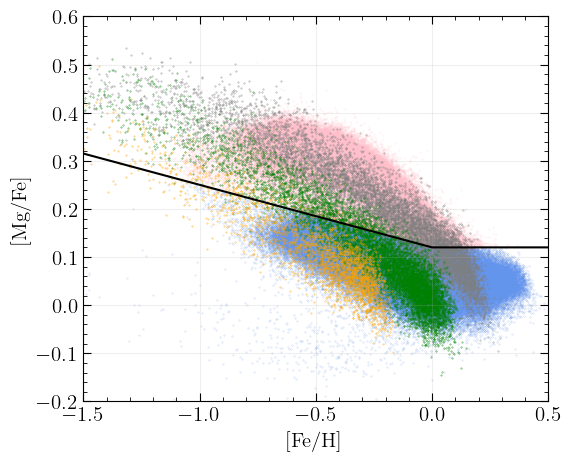

In [25]:
fig = plt.figure(figsize=(6,5))

plt.scatter(data_low_alpha['FE_H'], data_low_alpha['MG_FE'], alpha = 0.5, color = 'cornflowerblue', s = 0.05)
plt.scatter(data_high_alpha['FE_H'], data_high_alpha['MG_FE'], alpha = 0.5, color = 'pink', s = 0.05)

for i in range(len(gal1_dfs)):
    galaxy1_df = gal1_dfs[i]
    galaxy1 = sfr_1_gals[i]
    plt.scatter(galaxy1_df['Fe_H'], galaxy1_df['O_Fe'], s = 0.1, label = rf'SFR1, $\tau_* = {galaxy1.tau_star_arr[0]} , \eta = {galaxy1.eta_arr[0]} $', color = 'gray', alpha = 0.8)

for i in range(len(gal2_dfs)):
    galaxy2_df = gal2_dfs[i]
    galaxy2 = sfr_2_gals[i]
    plt.scatter(galaxy2_df['Fe_H'], galaxy2_df['O_Fe'], s = 0.1, label = rf'SFR1, $\tau_* = {galaxy2.tau_star_arr[0]} , \eta = {galaxy2.eta_arr[0]} $', color = 'green', alpha = 0.8)

for i in range(len(gal3_dfs)):
    galaxy3_df = gal3_downsampleds[i]
    galaxy3 = sfr_3_gals[i]
    plt.scatter(galaxy3_df['Fe_H'], galaxy3_df['O_Fe'], s = 0.1, label = rf'SFR1, $\tau_* = {galaxy3.tau_star_arr[0]} , \eta = {galaxy3.eta_arr[0]} $', color = 'orange', alpha = 0.8)


plt.plot(feh_line, mgfe_line, color = 'black')


plt.grid('True', alpha = 0.2)
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.ylim(-0.2,0.6)
plt.xlim(-1.5,0.5)

In [26]:
# Combine each galaxy's list of DataFrames
gal1_dfs_all = pd.concat(gal1_dfs, ignore_index=True)
gal2_dfs_all = pd.concat(gal2_dfs, ignore_index=True)
gal3_dfs_all = pd.concat(gal3_dfs, ignore_index=True)

# Combine ALL mock stars into one big DataFrame
all_mock_stars = pd.concat([gal1_dfs_all, gal2_dfs_all, gal3_dfs_all], ignore_index=True)

In [32]:
all_mock_stars.to_csv("all_mock_stars.csv", index=False)

In [28]:
# Compute MG_FE boundary for each mock star individually
boundary_mgfe = np.where(
    all_mock_stars['Fe_H'] < 0,
    0.12 - 0.13 * all_mock_stars['Fe_H'],  # negative metallicity
    0.12                                   # positive metallicity
)

# Now you can compare safely
mask_high = all_mock_stars['O_Fe'] > boundary_mgfe
mock_highalphas = all_mock_stars[mask_high]
mock_lowalphas = all_mock_stars[~mask_high]

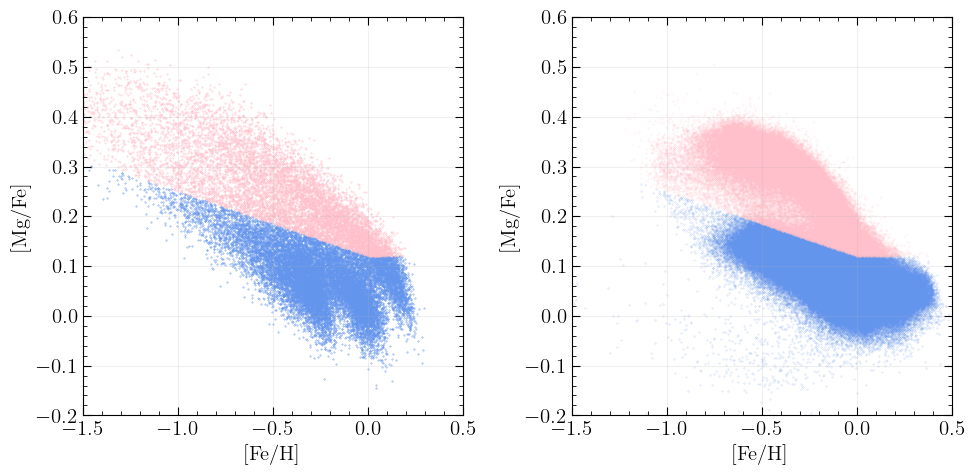

In [29]:
fig = plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(mock_lowalphas['Fe_H'], mock_lowalphas['O_Fe'], s = 0.1, color = 'cornflowerblue')
plt.scatter(mock_highalphas['Fe_H'], mock_highalphas['O_Fe'], s = 0.1, color = 'pink')
plt.grid('True', alpha = 0.2)
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.ylim(-0.2,0.6)
plt.xlim(-1.5,0.5)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['FE_H'], data_low_alpha['MG_FE'], alpha = 0.5, color = 'cornflowerblue', s = 0.05)
plt.scatter(data_high_alpha['FE_H'], data_high_alpha['MG_FE'], alpha = 0.5, color = 'pink', s = 0.05)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.ylim(-0.2,0.6)
plt.xlim(-1.5,0.5)


plt.tight_layout()

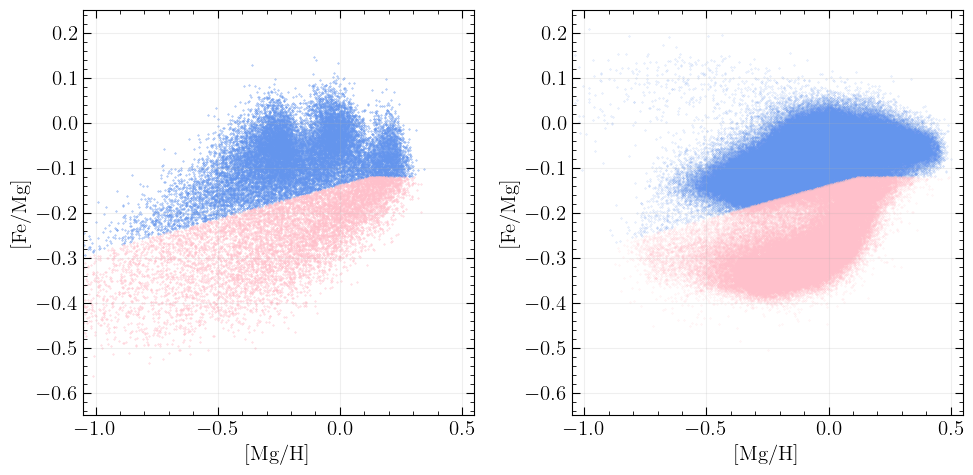

In [30]:
fig = plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(mock_lowalphas['O_H'], mock_lowalphas['Fe_O'], s = 0.1, color = 'cornflowerblue')
plt.scatter(mock_highalphas['O_H'], mock_highalphas['Fe_O'], s = 0.1, color = 'pink')
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.5, color = 'cornflowerblue', s = 0.05)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.5, color = 'pink', s = 0.05)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)


plt.tight_layout()

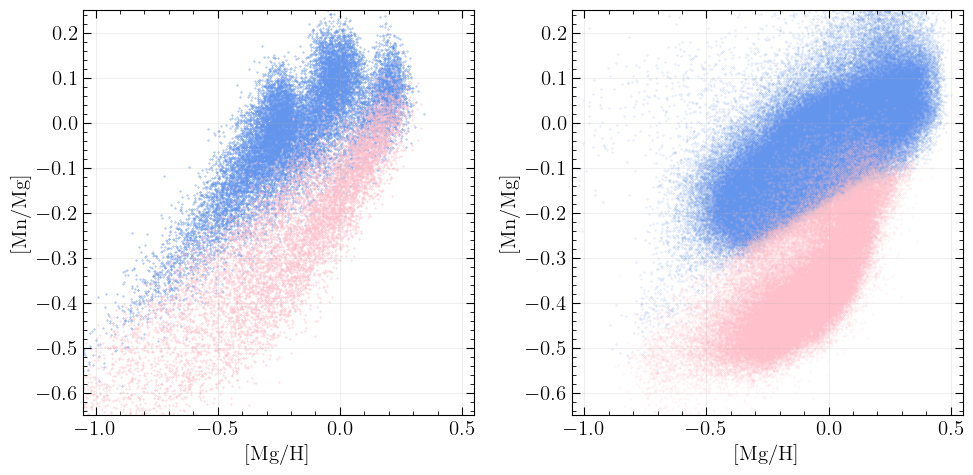

In [31]:
fig = plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(mock_lowalphas['O_H'], mock_lowalphas['Mn_O'], s = 0.1, color = 'cornflowerblue')
plt.scatter(mock_highalphas['O_H'], mock_highalphas['Mn_O'], s = 0.1, color = 'pink')
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.5, color = 'cornflowerblue', s = 0.05)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.5, color = 'pink', s = 0.05)
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.tight_layout()